# Classificação Binária
## Previsão de Aprovação de Empréstimo Pessoal

Neste notebook, construiremos um modelo de **classificação binária** para prever se um banco vai **aprovar** (1) ou **recusar** (0) o empréstimo pessoal solicitado por um cliente, com base em informações financeiras.

A diferença em relação à regressão linear é que aqui **a variável alvo é categórica** (apenas duas opções), e não numérica contínua.

Usaremos o algoritmo **Regressão Logística**, que estima a probabilidade de a classe ser 1 através da função sigmoide:

$$P(y=1 \mid x) = \frac{1}{1 + e^{-(b_0 + b_1 x_1 + \dots + b_n x_n)}}$$

Se essa probabilidade for maior que um limiar (geralmente 0,5), prevemos a classe 1; caso contrário, 0.

## 1. Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
)

sns.set_style('whitegrid')

## 2. Carregamento dos Dados

O dataset contém 400 registros de clientes que solicitaram empréstimo pessoal. Cada linha tem informações financeiras e o resultado da análise:

- `renda_mensal` — renda mensal declarada (R\$)
- `score_credito` — pontuação de crédito (300 a 850)
- `divida_atual` — total de dívidas atuais (R\$)
- `idade` — idade do solicitante (anos)
- `emprestimo_aprovado` — **alvo**: 1 = aprovado, 0 = recusado

In [2]:
df = pd.read_csv('dados_aprovacao_emprestimo.csv')
print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head(10)

Dimensões: 400 linhas × 5 colunas


,renda_mensal,score_credito,divida_atual,idade,emprestimo_aprovado
0,19687.97,306,23875.29,63,0
1,11813.64,466,38071.63,23,0
2,21677.05,584,45166.39,39,0
3,17888.15,806,36034.80,42,1
4,3713.17,706,48160.56,59,0
5,24427.13,730,39100.26,26,1
6,19386.78,600,43340.07,41,1
7,19972.51,360,5705.20,27,0
8,4510.67,515,36620.68,59,0
9,12084.07,849,22004.43,51,1


In [3]:
df.describe().round(2)

,renda_mensal,score_credito,divida_atual,idade,emprestimo_aprovado
count,400.00,400.00,400.00,400.00,400.00
mean,13168.84,574.40,24948.24,44.68,0.40
std,6698.07,159.07,14917.91,14.18,0.49
min,1673.01,302.00,61.65,20.00,0.00
25%,7137.98,435.00,12113.59,33.00,0.00
50%,13048.60,580.00,24507.70,43.50,0.00
75%,19317.60,709.00,38334.55,57.00,1.00
max,24820.83,850.00,49937.17,69.00,1.00


## 3. Análise Exploratória

### 3.1 Balanceamento das Classes

Um passo essencial em classificação é olhar a distribuição da variável alvo. Se as classes estiverem muito desbalanceadas, o modelo pode aprender a sempre prever a classe majoritária.

Distribuição da variável alvo:
  Recusado (0): 242 amostras (60.5%)
  Aprovado (1): 158 amostras (39.5%)


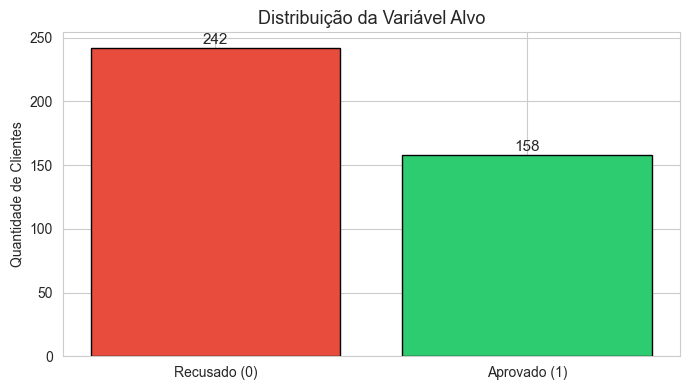

In [4]:
contagem = df['emprestimo_aprovado'].value_counts()
proporcao = df['emprestimo_aprovado'].value_counts(normalize=True)

print('Distribuição da variável alvo:')
for classe, qtd in contagem.items():
    label = 'Aprovado' if classe == 1 else 'Recusado'
    print(f'  {label} ({classe}): {qtd} amostras ({proporcao[classe]:.1%})')

plt.figure(figsize=(7, 4))
cores = ['#e74c3c', '#2ecc71']
plt.bar(['Recusado (0)', 'Aprovado (1)'], contagem.sort_index(), color=cores, edgecolor='black')
plt.title('Distribuição da Variável Alvo', fontsize=13)
plt.ylabel('Quantidade de Clientes')
for i, v in enumerate(contagem.sort_index()):
    plt.text(i, v + 3, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

### 3.2 Distribuição das Variáveis por Classe

Vamos comparar a distribuição de cada variável entre clientes aprovados e recusados, para ter uma intuição de quais features podem ajudar o modelo.

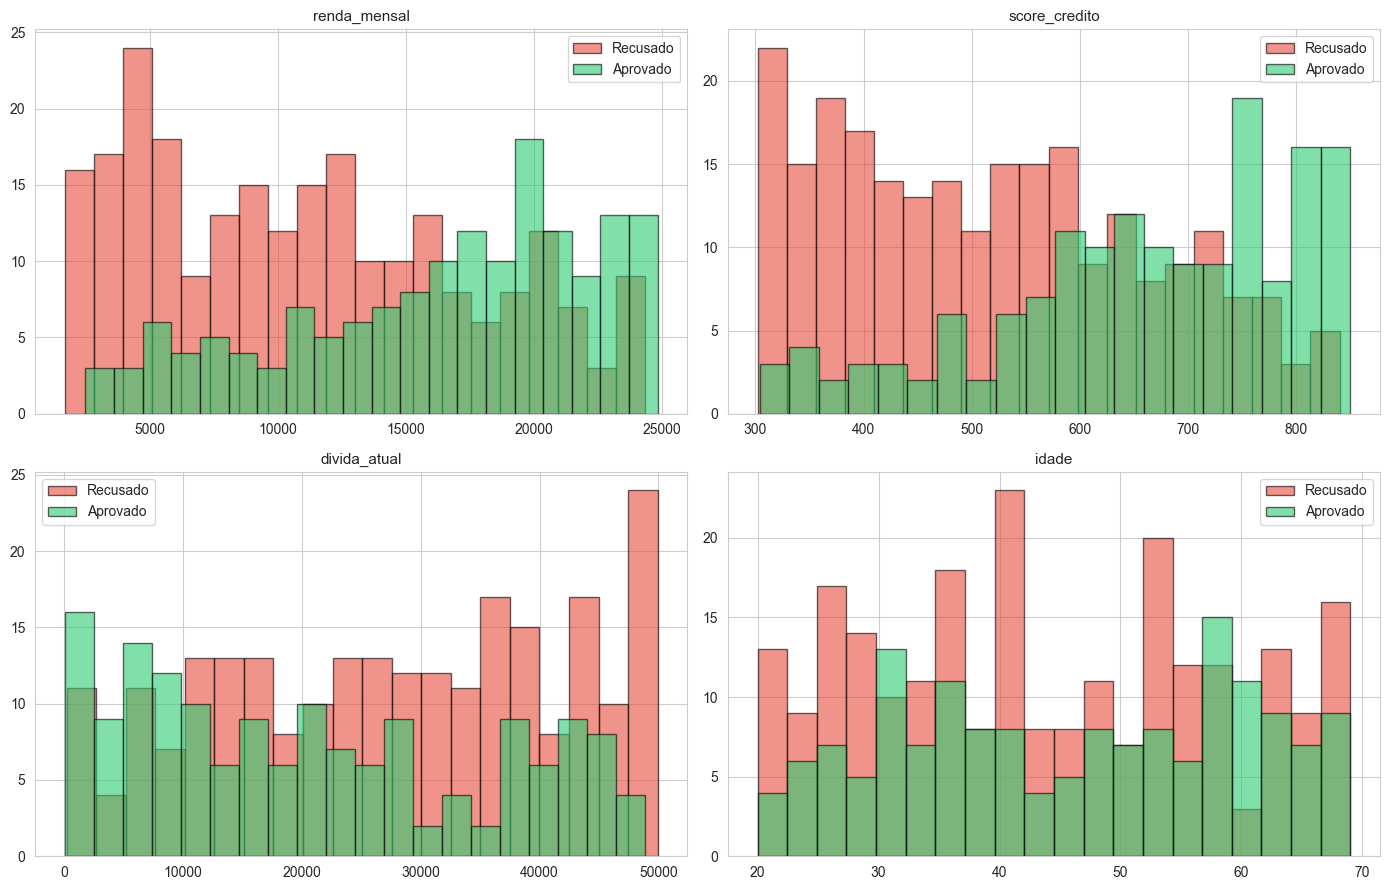

In [5]:
variaveis = ['renda_mensal', 'score_credito', 'divida_atual', 'idade']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(variaveis):
    for classe, cor, label in [(0, '#e74c3c', 'Recusado'), (1, '#2ecc71', 'Aprovado')]:
        axes[i].hist(df[df['emprestimo_aprovado'] == classe][col],
                     bins=20, alpha=0.6, color=cor, edgecolor='black', label=label)
    axes[i].set_title(col, fontsize=11)
    axes[i].legend()

plt.tight_layout()
plt.show()

### 3.3 Correlação entre as Variáveis

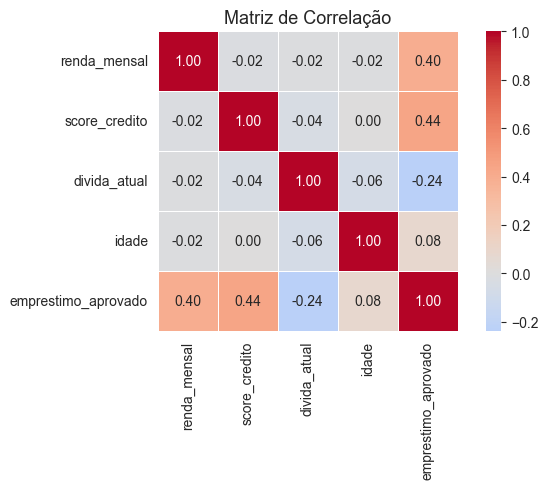

In [6]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlação', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Preparação dos Dados

Vamos:
1. Separar features (X) e alvo (y).
2. Dividir em treino e teste (80% / 20%).
3. **Padronizar** as variáveis numéricas com `StandardScaler`.

A padronização é importante para a regressão logística porque o algoritmo é sensível à escala das features (renda em milhares vs idade em dezenas).

In [7]:
X = df.drop(columns='emprestimo_aprovado')
y = df['emprestimo_aprovado']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_treino.shape[0]} amostras')
print(f'Teste:  {X_teste.shape[0]} amostras')
print(f'\nProporção de aprovados no treino: {y_treino.mean():.1%}')
print(f'Proporção de aprovados no teste:  {y_teste.mean():.1%}')

Treino: 320 amostras
Teste:  80 amostras

Proporção de aprovados no treino: 39.4%
Proporção de aprovados no teste:  40.0%


In [8]:
scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)

print('Após padronização, cada variável tem média ~0 e desvio padrão ~1.')
pd.DataFrame(X_treino_scaled, columns=X.columns).describe().round(2).loc[['mean', 'std']]

Após padronização, cada variável tem média ~0 e desvio padrão ~1.


,renda_mensal,score_credito,divida_atual,idade
mean,0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0


## 5. Treinamento do Modelo

A `LogisticRegression` ajusta os coeficientes que melhor separam as duas classes, minimizando a função de perda *log-loss*.

In [9]:
modelo = LogisticRegression(random_state=42, max_iter=1000)
modelo.fit(X_treino_scaled, y_treino)

print(f'Intercepto (b₀): {modelo.intercept_[0]:+.4f}\n')
print('Coeficientes:')
for nome, coef in zip(X.columns, modelo.coef_[0]):
    print(f'  {nome:<18s} {coef:>+.4f}')

Intercepto (b₀): -0.7070

Coeficientes:
  renda_mensal       +1.1295
  score_credito      +1.3903
  divida_atual       -0.6166
  idade              +0.2162


## 6. Interpretação dos Coeficientes

Como padronizamos os dados, os coeficientes estão em escala comparável. Lendo:

- **Coeficiente positivo** → aumentar essa variável **aumenta** a chance de aprovação.
- **Coeficiente negativo** → aumentar essa variável **diminui** a chance de aprovação.
- O **valor absoluto** indica a força do efeito.

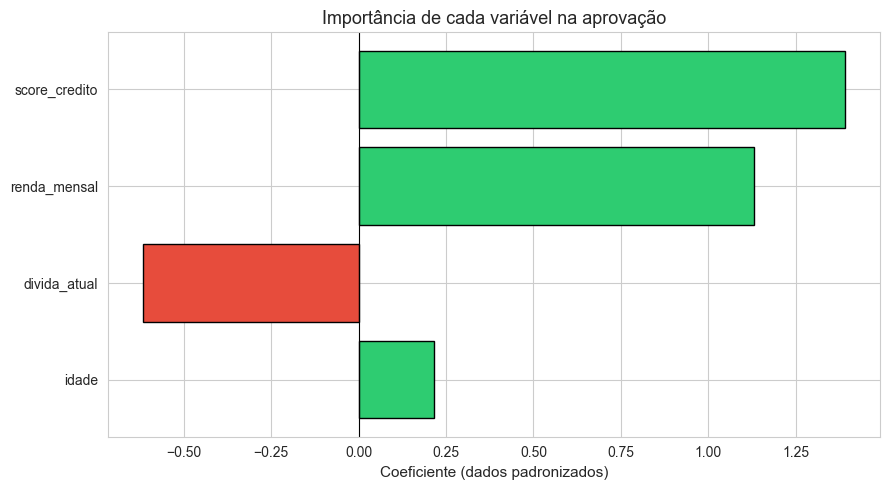

In [10]:
coef_df = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': modelo.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=True)

plt.figure(figsize=(9, 5))
cores = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coeficiente']]
plt.barh(coef_df['Variável'], coef_df['Coeficiente'], color=cores, edgecolor='black')
plt.xlabel('Coeficiente (dados padronizados)', fontsize=11)
plt.title('Importância de cada variável na aprovação', fontsize=13)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 7. Previsões no Conjunto de Teste

O modelo retorna duas coisas:
- `predict()` → a classe prevista (0 ou 1).
- `predict_proba()` → a probabilidade de cada classe.

In [11]:
y_pred = modelo.predict(X_teste_scaled)
y_proba = modelo.predict_proba(X_teste_scaled)[:, 1]  # probabilidade da classe 1

resultado = pd.DataFrame({
    'Renda': X_teste['renda_mensal'].values,
    'Score': X_teste['score_credito'].values,
    'Dívida': X_teste['divida_atual'].values,
    'Real': y_teste.values,
    'Previsto': y_pred,
    'Prob. Aprovação': y_proba.round(3)
})
resultado.head(10)

,Renda,Score,Dívida,Real,Previsto,Prob. Aprovação
0,14097.60,806,2258.66,1,1,0.925
1,11894.38,641,14044.82,0,1,0.579
2,3734.75,699,47076.94,0,0,0.106
3,8112.52,577,19618.45,0,0,0.204
4,11296.90,428,43835.54,0,0,0.033
5,12176.47,649,21899.48,0,1,0.514
6,23233.78,764,12179.84,1,1,0.954
7,6255.54,401,33729.87,0,0,0.026
8,3765.19,504,21919.31,0,0,0.051
9,13274.55,449,27042.83,0,0,0.099


## 8. Avaliação do Modelo

### 8.1 Métricas Principais

Em classificação, **acurácia** sozinha não conta a história inteira — especialmente em datasets desbalanceados. As principais métricas são:

- **Acurácia**: % total de acertos.
- **Precisão**: dos que o modelo previu como aprovados, quantos foram realmente aprovados? (Penaliza falsos positivos.)
- **Recall (sensibilidade)**: dos clientes realmente aprovados, quantos o modelo identificou? (Penaliza falsos negativos.)
- **F1-Score**: média harmônica entre precisão e recall — útil quando precisamos equilibrar os dois.

In [12]:
acc = accuracy_score(y_teste, y_pred)
prec = precision_score(y_teste, y_pred)
rec = recall_score(y_teste, y_pred)
f1 = f1_score(y_teste, y_pred)

print('╔══════════════════════════════════════╗')
print('║      MÉTRICAS DE AVALIAÇÃO           ║')
print('╠══════════════════════════════════════╣')
print(f'║  Acurácia:  {acc:.4f}                   ║')
print(f'║  Precisão:  {prec:.4f}                   ║')
print(f'║  Recall:    {rec:.4f}                   ║')
print(f'║  F1-Score:  {f1:.4f}                   ║')
print('╚══════════════════════════════════════╝')

print('\n--- classification_report do scikit-learn ---')
print(classification_report(y_teste, y_pred,
                            target_names=['Recusado', 'Aprovado']))

╔══════════════════════════════════════╗
║      MÉTRICAS DE AVALIAÇÃO           ║
╠══════════════════════════════════════╣
║  Acurácia:  0.7750                   ║
║  Precisão:  0.7059                   ║
║  Recall:    0.7500                   ║
║  F1-Score:  0.7273                   ║
╚══════════════════════════════════════╝

--- classification_report do scikit-learn ---
              precision    recall  f1-score   support

    Recusado       0.83      0.79      0.81        48
    Aprovado       0.71      0.75      0.73        32

    accuracy                           0.78        80
   macro avg       0.77      0.77      0.77        80
weighted avg       0.78      0.78      0.78        80



### 8.2 Matriz de Confusão

A matriz mostra, para cada combinação de classe real × classe prevista, quantas amostras caíram ali.

|              | Previsto 0 | Previsto 1 |
|--------------|------------|------------|
| **Real 0**   | VN         | FP         |
| **Real 1**   | FN         | VP         |

- **VN** (Verdadeiro Negativo): recusou e era pra recusar mesmo.
- **FP** (Falso Positivo): aprovou um cliente que deveria ter sido recusado — risco para o banco!
- **FN** (Falso Negativo): recusou um cliente que deveria ter sido aprovado — perda de cliente.
- **VP** (Verdadeiro Positivo): aprovou e era pra aprovar.

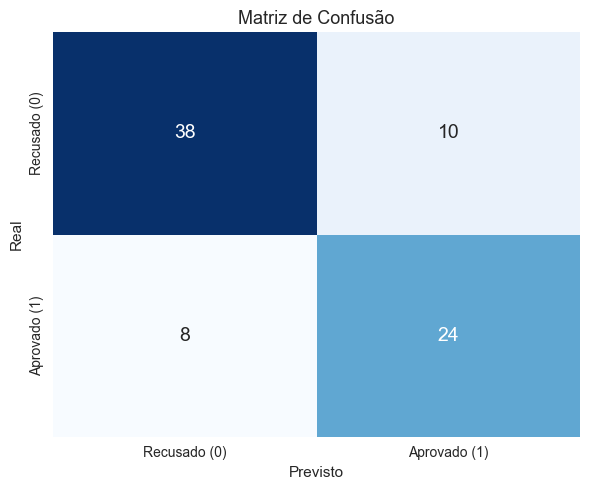

Verdadeiros Negativos: 38
Falsos Positivos:      10
Falsos Negativos:      8
Verdadeiros Positivos: 24


In [13]:
cm = confusion_matrix(y_teste, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Recusado (0)', 'Aprovado (1)'],
            yticklabels=['Recusado (0)', 'Aprovado (1)'],
            cbar=False, annot_kws={'size': 14})
plt.xlabel('Previsto', fontsize=11)
plt.ylabel('Real', fontsize=11)
plt.title('Matriz de Confusão', fontsize=13)
plt.tight_layout()
plt.show()

vn, fp, fn, vp = cm.ravel()
print(f'Verdadeiros Negativos: {vn}')
print(f'Falsos Positivos:      {fp}')
print(f'Falsos Negativos:      {fn}')
print(f'Verdadeiros Positivos: {vp}')

### 8.3 Curva ROC e AUC

A **curva ROC** mostra o trade-off entre **taxa de verdadeiros positivos** (recall) e **taxa de falsos positivos** para diferentes limiares de decisão.

A **AUC** (área sob a curva) resume a curva em um único número: 1.0 = modelo perfeito, 0.5 = aleatório.

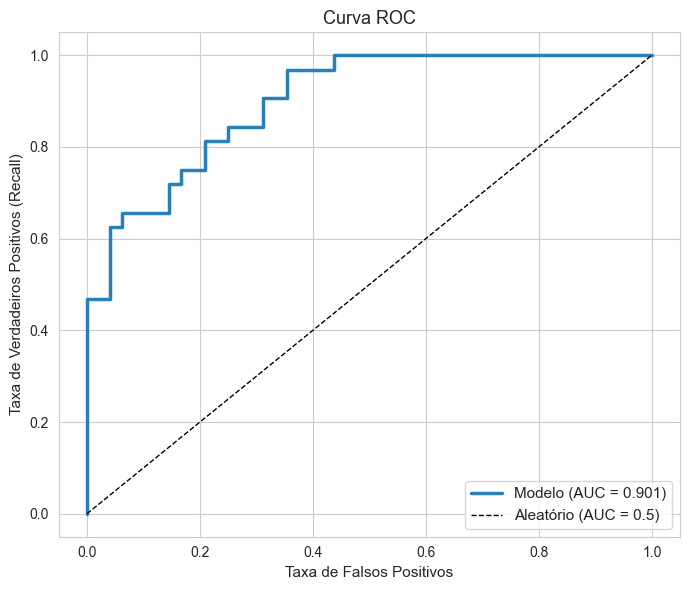

AUC = 0.9010


In [14]:
fpr, tpr, thresholds = roc_curve(y_teste, y_proba)
auc = roc_auc_score(y_teste, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#2980b9', linewidth=2.5, label=f'Modelo (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório (AUC = 0.5)')
plt.xlabel('Taxa de Falsos Positivos', fontsize=11)
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)', fontsize=11)
plt.title('Curva ROC', fontsize=13)
plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

print(f'AUC = {auc:.4f}')

## 9. Ajustando o Limiar de Decisão

Por padrão, classificamos como "Aprovado" quando `prob >= 0.5`. Podemos mudar esse limiar para favorecer **precisão** (mais conservador) ou **recall** (mais permissivo).

In [15]:
limiares = [0.3, 0.4, 0.5, 0.6, 0.7]

print(f'{"Limiar":<8s}{"Acurácia":<12s}{"Precisão":<12s}{"Recall":<12s}{"F1":<10s}')
print('-' * 54)
for t in limiares:
    y_pred_t = (y_proba >= t).astype(int)
    print(f'{t:<8.2f}'
          f'{accuracy_score(y_teste, y_pred_t):<12.4f}'
          f'{precision_score(y_teste, y_pred_t, zero_division=0):<12.4f}'
          f'{recall_score(y_teste, y_pred_t):<12.4f}'
          f'{f1_score(y_teste, y_pred_t):<10.4f}')

Limiar  Acurácia    Precisão    Recall      F1        
------------------------------------------------------
0.30    0.7750      0.6591      0.9062      0.7632    
0.40    0.7875      0.7027      0.8125      0.7536    
0.50    0.7750      0.7059      0.7500      0.7273    
0.60    0.8000      0.8077      0.6562      0.7241    
0.70    0.8000      0.9000      0.5625      0.6923    


**Como escolher o limiar?**

- Se o custo de **falsos positivos** é alto (aprovar quem não deveria → calote), **aumente** o limiar.
- Se o custo de **falsos negativos** é alto (recusar bons clientes → perda de receita), **diminua** o limiar.

## 10. Fazendo Novas Previsões

Com o modelo treinado, podemos avaliar novos clientes.

In [16]:
novos_clientes = pd.DataFrame({
    'renda_mensal':   [3500,   8000,  15000,  22000,  6500],
    'score_credito':  [420,    580,    720,    810,    350],
    'divida_atual':   [12000,  20000,  5000,   3000,   38000],
    'idade':          [25,     38,     45,     52,     30],
})

novos_scaled = scaler.transform(novos_clientes)
previsoes = modelo.predict(novos_scaled)
probabilidades = modelo.predict_proba(novos_scaled)[:, 1]

for i, (_, cliente) in enumerate(novos_clientes.iterrows()):
    decisao = 'APROVADO' if previsoes[i] == 1 else 'RECUSADO'
    print(f'Cliente {i+1}: renda R$ {cliente.renda_mensal:>6,.0f} | '
          f'score {cliente.score_credito:>3.0f} | '
          f'dívida R$ {cliente.divida_atual:>6,.0f} → '
          f'{decisao} (prob. aprovação: {probabilidades[i]:.1%})')

Cliente 1: renda R$  3,500 | score 420 | dívida R$ 12,000 → RECUSADO (prob. aprovação: 3.1%)
Cliente 2: renda R$  8,000 | score 580 | dívida R$ 20,000 → RECUSADO (prob. aprovação: 19.8%)
Cliente 3: renda R$ 15,000 | score 720 | dívida R$  5,000 → APROVADO (prob. aprovação: 85.2%)
Cliente 4: renda R$ 22,000 | score 810 | dívida R$  3,000 → APROVADO (prob. aprovação: 98.1%)
Cliente 5: renda R$  6,500 | score 350 | dívida R$ 38,000 → RECUSADO (prob. aprovação: 1.1%)


---

## Conclusão

Neste notebook, percorremos todo o fluxo de um problema de **classificação binária**:

1. **Exploração** — entendemos a distribuição das classes e variáveis.
2. **Preparação** — fizemos a divisão treino/teste e padronizamos os dados.
3. **Modelagem** — treinamos uma regressão logística.
4. **Interpretação** — entendemos como cada variável influencia a decisão.
5. **Avaliação** — medimos o desempenho com várias métricas (não só acurácia!).
6. **Ajuste fino** — vimos como mudar o limiar muda o comportamento do modelo.

No próximo notebook, vamos estender essa ideia para mais de duas classes — a **classificação multiclasse**.